# Check results of DFT as they come out

In [1]:
import os
import re
import copy
import numpy as np
import glob
import sys
import ase

import rmgpy.chemkin
import rmgpy.kinetics
import rmgpy.tools.uncertainty


import arkane.modelchem
import arkane.ess
import arkane.encorr
import arkane.common

DFT_DIR = os.path.join(os.environ['AUTOSCIENCE_REPO'], 'dft')
sys.path.append(DFT_DIR)
import autotst_wrapper

sys.path.append(os.environ['DATABASE_DIR'])
import database_fun


import matplotlib.pyplot as plt
%matplotlib inline

/home/harris.se/rmg/RMG-Py/rmgpy/rmg/reactors.py:53: RuntimeWarning: Unable to import Julia dependencies, original error: [Errno 2] No such file or directory: 'julia': 'julia'
  warnings.warn("Unable to import Julia dependencies, original error: " + str(e), RuntimeWarning)


Loading DFT database from /work/westgroup/harris.se/autoscience/reaction_calculator/database


In [2]:
def get_i_thing(thing, thing_list, pdep_specific=False):
    if not pdep_specific:
        for i in range(len(thing_list)):
            if thing.is_isomorphic(thing_list[i]):
                return i
        return -1
    
    for i in range(len(thing_list)):
        if thing.is_isomorphic(thing_list[i]):
            if (isinstance(thing, rmgpy.rmg.pdep.PDepReaction) and isinstance(thing_list[i], rmgpy.rmg.pdep.PDepReaction)) or \
                    (not isinstance(thing, rmgpy.rmg.pdep.PDepReaction) and not isinstance(thing_list[i], rmgpy.rmg.pdep.PDepReaction)):
                return i
    return -1

def get_reaction_species(reaction):
    if type(reaction) == int:
        reaction = database_fun.index2reaction(reaction)
        
    reaction_string = database_fun.get_unique_string(reaction)
    tokens = reaction_string.split('=')
    reactants = [int(i) for i in tokens[0].split('+')]
    products = [int(i) for i in tokens[-1].split('+')]
    return reactants + products

def get_reverse_reaction(reaction):
    assert reaction.kinetics is not None
    rev_reaction = copy.deepcopy(reaction)
    tmp_reactants = rev_reaction.reactants
    rev_reaction.reactants = rev_reaction.products
    rev_reaction.products = tmp_reactants
    rev_reaction.kinetics = reaction.generate_reverse_rate_coefficient()
    return rev_reaction

def reactions_in_same_direction(reaction1, reaction2):
    assert reaction1.is_isomorphic(reaction2), f'Reactions are not even isomorphic {reaction1} {reaction2}'
    if len(reaction1.reactants) != len(reaction2.reactants):
        return False
    reactants_to_match = [r for r in reaction1.reactants]
    counter = 0
    while reactants_to_match:
        for i in range(len(reaction2.reactants)):
            if reaction2.reactants[i].is_isomorphic(reactants_to_match[0]):
                reactants_to_match.remove(reactants_to_match[0])
                break
        else:
            return False
        
        
        if counter >= len(reaction1.reactants):
            return False
        counter += 1
        
    return True


def plot_kinetics(rxns, labels=None, title=None):
    """Function for plotting reaction kinetics
    Takes in a list of RMG reactions (rmgpy.reaction.Reaction) or a single reaction
    """
    plt.xlabel('1000 / T (K^-1)')
    plt.ylabel('log10(k)')
    linestyles = ['solid', 'solid', 'dashed', 'dashed']
    if type(rxns) != list:
        rxns = [rxns]

    T = np.linspace(300, 3000, 1001)
    for m, rxn in enumerate(rxns):
        k = np.zeros(len(T))
        for i in range(0, len(T)):
            k[i] = rxn.get_rate_coefficient(T[i], 101325)
        plt.plot(1000.0 / T, np.log10(k), linestyle=linestyles[m % len(linestyles)])

    if labels:
        plt.legend(labels)
    if title:
        plt.title(title)
    plt.ylim([-10, 10])
    plt.show()

# Identify relevant changelist

In [11]:
# pick the change_list to focus on
rmg_min_1_rxns = [4721]
rmg_min_1_sp = [4, 57, 280, 60, 61, 73, 21, 72, 32]
for r in rmg_min_1_rxns:
    rmg_min_1_sp += get_reaction_species(r)

sp_changelist = rmg_min_1_sp
rxn_changelist = rmg_min_1_rxns
sp_changelist = sorted(list(set(sp_changelist)))
rxn_changelist = sorted(list(set(rxn_changelist)))
    


In [12]:
# load the thermo
entries = []
for species_index in sp_changelist:
    lib_path = os.path.join(DFT_DIR, 'thermo', f'species_{species_index:04}', 'arkane', 'RMG_libraries')
    if not os.path.exists(lib_path):
        print(f'Missing species {species_index}')
        continue
    ark_thermo_database = rmgpy.data.thermo.ThermoDatabase()
    ark_thermo_database.load_libraries(lib_path)
    for key in ark_thermo_database.libraries['thermo'].entries.keys():
        entry = ark_thermo_database.libraries['thermo'].entries[key]
        entry.index = species_index
        entry.label = entry.item.smiles
        entries.append(entry)
print(f'{len(entries)} thermo entries')
sp_entries = [e.item for e in entries]


# Load the kinetics
k_entries = []
for reaction_index in rxn_changelist:
    lib_path = os.path.join(DFT_DIR, 'kinetics', f'reaction_{reaction_index:06}', 'arkane', 'RMG_libraries')
    if not os.path.exists(lib_path):
        print(f'Missing reaction {reaction_index}')
        continue
    ark_kinetics_database = rmgpy.data.kinetics.KineticsDatabase()
    ark_kinetics_database.load_libraries(lib_path)
    for key in ark_kinetics_database.libraries[''].entries.keys():
        entry = ark_kinetics_database.libraries[''].entries[key]
        entry.index = reaction_index
        k_entries.append(entry)
print(f'{len(k_entries)} kinetics entries')
rxn_entries = [e.item for e in k_entries]

Missing species 5
Missing species 19
Missing species 32
Missing species 57
Missing species 61
Missing species 72
Missing species 73
Missing species 280
3 thermo entries
Missing reaction 4721
0 kinetics entries


# Compare Species Thermo Results to Best References

In [14]:
chemkin_fileA = '/work/westgroup/harris.se/autoscience/fuels/butane/official/aramco/chem_annotated.inp'
dict_fileA = '/work/westgroup/harris.se/autoscience/fuels/butane/official/aramco/species_dictionary.txt'
species_listA, reaction_listA = rmgpy.chemkin.load_chemkin_file(chemkin_fileA, dict_fileA)

In [16]:
# Need to load a thermo database to get GAV
database = rmgpy.data.rmg.RMGDatabase()

thermo_libraries = [
    'BurkeH2O2',
    'primaryThermoLibrary',
]

database.load(
    path = rmgpy.settings['database.directory'],
    thermo_libraries = thermo_libraries,
    transport_libraries = [],
    reaction_libraries = [],
    seed_mechanisms = [],
    kinetics_families = 'default',
    kinetics_depositories = [],
    depository = False,
)


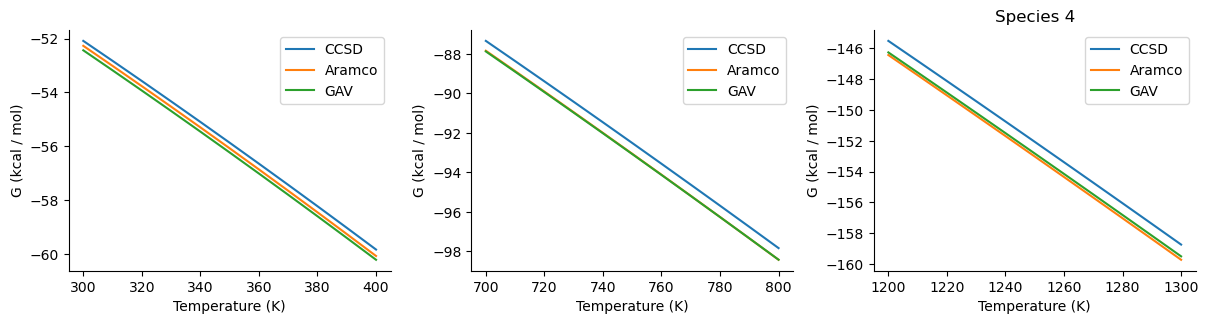

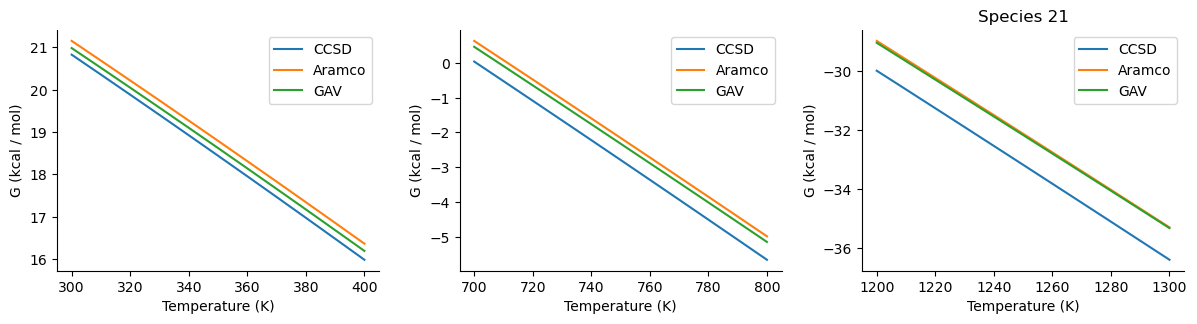

SPECIES 60 DIFFERS FROM ARAMCO!!!
SPECIES 60 DIFFERS FROM GAV!!!


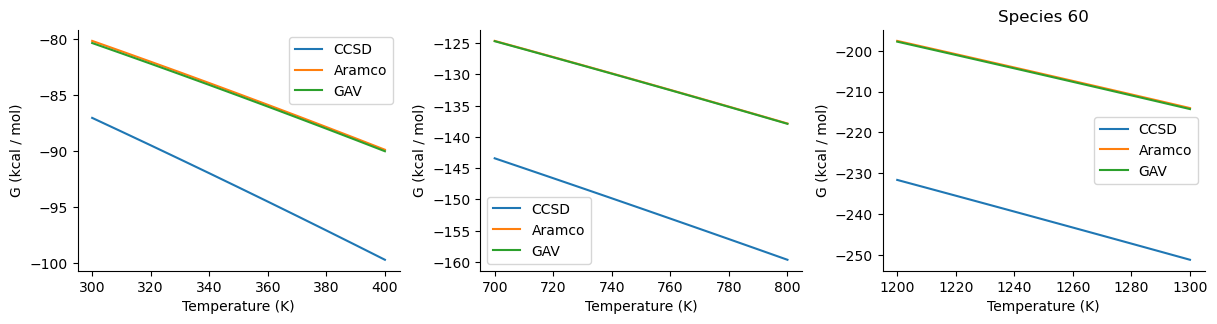

In [20]:
ARAMCO_DIFF_THRESHOLD = 2.0  # kcal/mol
GAV_DIFF_THRESHOLD = 3.0  # kcal/mol

for e in entries:
    species_index = e.index
    
    aramco_thermo = None
    indexA = get_i_thing(rmgpy.species.Species(molecule=[e.item]), species_listA)
    if indexA >= 0:
        aramco_thermo = species_listA[indexA].thermo
    else:
        print(f'Aramco doesnt have {species_index}')
    
    
    GAV_species = rmgpy.species.Species(molecule=[e.item])
    GAV_species.thermo = database.thermo.get_thermo_data(GAV_species)
    
    
    N = 11
    T_lows = np.linspace(300, 400, N)
    T_meds = np.linspace(700, 800, N)
    T_highs = np.linspace(1200, 1300, N)

    G_calc_low = np.zeros_like(T_lows)
    G_calc_med = np.zeros_like(T_meds)
    G_calc_high = np.zeros_like(T_highs)
    for j in range(N):
        G_calc_low[j] = e.data.get_free_energy(T_lows[j]) / 4184  # kcal/mol
        G_calc_med[j] = e.data.get_free_energy(T_meds[j]) / 4184  # kcal/mol
        G_calc_high[j] = e.data.get_free_energy(T_highs[j]) / 4184  # kcal/mol
        
    G_Aramco_low = np.zeros_like(T_lows) * np.nan
    G_Aramco_med = np.zeros_like(T_lows) * np.nan
    G_Aramco_high = np.zeros_like(T_lows) * np.nan
    if aramco_thermo is not None:
        for j in range(N):
            G_Aramco_low[j] = aramco_thermo.get_free_energy(T_lows[j]) / 4184  # kcal/mol
            G_Aramco_med[j] = aramco_thermo.get_free_energy(T_meds[j]) / 4184  # kcal/mol
            G_Aramco_high[j] = aramco_thermo.get_free_energy(T_highs[j]) / 4184  # kcal/mol
            
    G_GAV_low = np.zeros_like(T_lows) * np.nan
    G_GAV_med = np.zeros_like(T_lows) * np.nan
    G_GAV_high = np.zeros_like(T_lows) * np.nan
    for j in range(N):
        G_GAV_low[j] = GAV_species.thermo.get_free_energy(T_lows[j]) / 4184  # kcal/mol
        G_GAV_med[j] = GAV_species.thermo.get_free_energy(T_meds[j]) / 4184  # kcal/mol
        G_GAV_high[j] = GAV_species.thermo.get_free_energy(T_highs[j]) / 4184  # kcal/mol
        
    
    # Look for big changes
    if np.any(np.abs(G_calc_low - G_Aramco_low) > ARAMCO_DIFF_THRESHOLD):
        print(f'SPECIES {species_index} DIFFERS FROM ARAMCO!!!')
    elif np.any(np.abs(G_calc_med - G_Aramco_med) > ARAMCO_DIFF_THRESHOLD):
        print(f'SPECIES {species_index} DIFFERS FROM ARAMCO!!!')
    elif np.any(np.abs(G_calc_high - G_Aramco_high) > ARAMCO_DIFF_THRESHOLD):
        print(f'SPECIES {species_index} DIFFERS FROM ARAMCO!!!')

        
    if np.any(np.abs(G_calc_low - G_GAV_low) > ARAMCO_DIFF_THRESHOLD):
        print(f'SPECIES {species_index} DIFFERS FROM GAV!!!')
    elif np.any(np.abs(G_calc_med - G_GAV_med) > ARAMCO_DIFF_THRESHOLD):
        print(f'SPECIES {species_index} DIFFERS FROM GAV!!!')
    elif np.any(np.abs(G_calc_high - G_GAV_high) > ARAMCO_DIFF_THRESHOLD):
        print(f'SPECIES {species_index} DIFFERS FROM GAV!!!')
    
    
    
    fig, ax = plt.subplots(1, 3)
    fig.set_size_inches(12, 3)
    fig.tight_layout()
    
    
    ax[0].plot(T_lows, G_calc_low)
    ax[0].plot(T_lows, G_Aramco_low)
    ax[0].plot(T_lows, G_GAV_low)
    
    ax[1].plot(T_meds, G_calc_med)
    ax[1].plot(T_meds, G_Aramco_med)
    ax[1].plot(T_meds, G_GAV_med)
    
    ax[2].plot(T_highs, G_calc_high)
    ax[2].plot(T_highs, G_Aramco_high)
    ax[2].plot(T_highs, G_GAV_high)
    
    
    
    labels = ['CCSD', 'Aramco', 'GAV']
    for i in range(3):
        ax[i].set_xlabel('Temperature (K)')
        ax[i].set_ylabel('G (kcal / mol)')
        ax[i].spines['right'].set_visible(False)
        ax[i].spines['top'].set_visible(False)
        ax[i].legend(labels)
    
    plt.title(f'Species {species_index}')
    plt.subplots_adjust(wspace=0.25)
    plt.show()
    

[4, 21, 60]